#  1. Project Overview


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2.Data Loading and Cleaning

In [ ]:
df = pd.read_csv('JobInd.csv')
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1561 entries, 0 to 1560
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1561 non-null   int64  
 1   job_title               1561 non-null   object 
 2   company                 1561 non-null   object 
 3   experience              1527 non-null   object 
 4   min exp                 1527 non-null   float64
 5   max exp                 1527 non-null   float64
 6   salary                  343 non-null    object 
 7   base salary             343 non-null    float64
 8   max salary              343 non-null    float64
 9   location                1528 non-null   object 
 10  jobListed(days ago)     1561 non-null   float64
 11  postedIn                1561 non-null   object 
 12  rating                  1124 non-null   float64
 13  reviews count           1124 non-null   float64
 14  details                 1528 non-null   

,0
Unnamed: 0,0
job_title,0
company,0
experience,34
min exp,34
max exp,34
salary,1218
base salary,1218
max salary,1218
location,33


In [ ]:
df =df.fillna(df.median(numeric_only=True))

In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ','_')
df.head()

,Unnamed:_0,job_title,company,experience,min_exp,max_exp,salary,base_salary,max_salary,location,jobListed(days_ago),postedIn,rating,reviews_count,details,salary_data_provide_by
0,0,JP Morgan Chase - Client Data Analyst (4-8 yrs),JP Morgan Chase,4-8 Yrs,4.0,8.0,NaN,360000.0,1330000.0,Hyderabad / Secunderabad,3.0,iimjobs,4.1,5300.0,"Banking, KYC, Banking Operations",NaN
1,1,Data Analyst - Bangalore,Schneider Electric,5-10 Yrs,5.0,10.0,₹ 8 - 16L/yr,800000.0,1600000.0,"Bangalore / Bengaluru, Bangalore Rural",4.0,Naukri,4.2,3500.0,"ERP, SAP, Data Analysis",Salary Listed by Company
2,2,Senior IT ATLAS Data Analyst and Integration S...,SAP Labs India Pvt. Ltd.,7-11 Yrs,7.0,11.0,NaN,360000.0,1330000.0,Bangalore / Bengaluru,7.0,Naukri,4.3,1500.0,"data quality, Data analysis, quality management",NaN
3,3,Consultant Data Analyst,Pfizer,2-6 Yrs,2.0,6.0,NaN,360000.0,1330000.0,Mumbai,3.0,Naukri,4.1,1700.0,"Power Bi, Commercial Operations, Data Management",NaN
4,4,Senior Data Analyst - Retail Liabilities,IDFC FIRST Bank,5-10 Yrs,5.0,10.0,NaN,360000.0,1330000.0,Mumbai,5.0,Naukri,4.5,2300.0,"Test strategy, Analytical, Manager Technology",NaN


# 3.Feature Engineering

In [ ]:
df['avg_exp'] = (df['min_exp'] + df['max_exp'])/2


In [ ]:
columns_to_drop=['Unnamed:_0','job_title','company','experience','min_exp', 'max_exp','salary', 'details','salary_data_provide_by']
df.drop(columns=columns_to_drop,  inplace=True)



In [ ]:
df.columns

Index(['base_salary', 'max_salary', 'jobListed(days_ago)', 'rating',
       'reviews_count', 'avg_exp',
       'location_Ahmedabad, Hyderabad / Secunderabad', 'location_Amod',
       'location_Aurangabad', 'location_Ballari',
       ...
       'location_Trichy, Chennai, Madurai\n\t\t\t\t\t\t\t\t\t\t\t\t\t+3 more',
       'location_Vadodara',
       'location_Vadodara, Ahmedabad, Rajkot\n\t\t\t\t\t\t\t\t\t\t\t\t\t+2 more',
       'location_Varanasi', 'location_Vijayawada', 'location_Visakhapatnam',
       'postedIn_Naukri', 'postedIn_bigshyft', 'postedIn_hirist',
       'postedIn_iimjobs'],
      dtype='object', length=203)

In [ ]:
df=pd.get_dummies(df, columns=['location','postedIn'],drop_first=True)

In [ ]:
X=df.drop(columns=['base_salary'])
y=df['base_salary']

# 4.Exploratory DataAnalysis

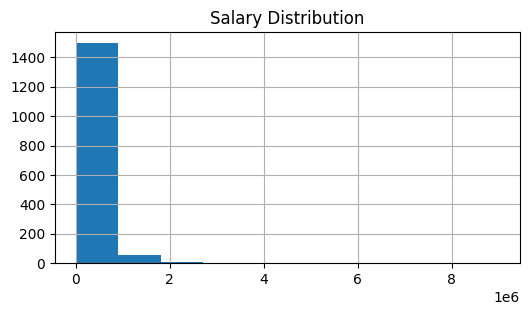

In [ ]:
#Salary Distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,3))
df['base_salary'].hist()
plt.title('Salary Distribution')
plt.show()


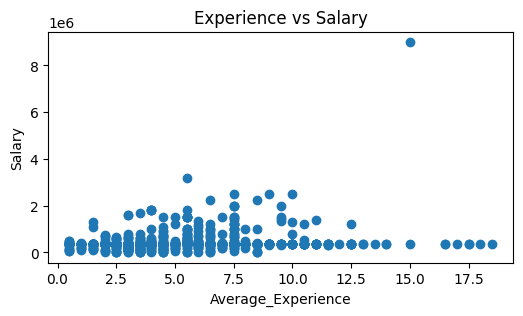

In [ ]:
#Experience vs Salary
fig, ax = plt.subplots(figsize=(6,3))
plt.scatter(df['avg_exp'], df['base_salary'])
plt.xlabel('Average_Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

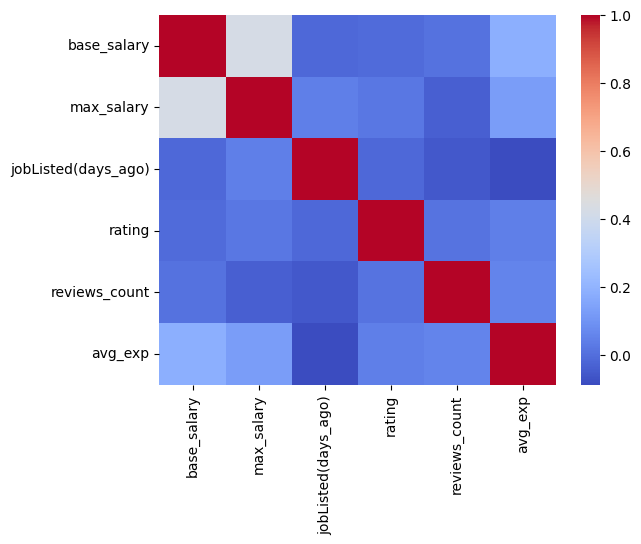

In [ ]:
#Correlation heatmap
import seaborn as sns
selected_columns = ['base_salary', 'max_salary', 'jobListed(days_ago)', 'rating','reviews_count', 'avg_exp']
df_subset= df[selected_columns]
corr_matrix = df_subset.corr()
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

## Statistical Analysis
Conduct hypothesis testing to determine if there's a significant
difference in ratings between jobs posted on 'Naukri' and 'iimjobs'.
○ Perform a correlation analysis between job ratings and reviews
count.

Conclusion:
Correlation analysis between company ratings and number of reviews shows a coefficient of 0.019, indicating almost no linear relationship. This suggests company ratings remain relatively stable regardless of review volume.

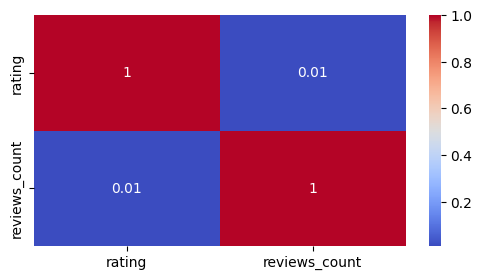

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))
selected_columns = ['rating','reviews_count']
df_subset= df[selected_columns]
corr_matrix = df_subset.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.show()

In [ ]:
naukri = df[df['postedIn_Naukri'] == 1]['rating'].dropna().values
iimjobs = df[df['postedIn_iimjobs'] == 1]['rating'].dropna().values

In [ ]:
from scipy.stats import ttest_ind
t_stat, p_value  = ttest_ind(naukri, iimjobs)
print('t-statistics:', t_stat)
print('P-value:', p_value)

t-statistics: -0.011482363020656054
P-value: 0.9908403180319918


## Conclusion:
 --- <0.05 is statistically significant
 --->0.05 not statistically significant
--p-value = 0.99, which is extremely high.
--We fail to reject the null hypothesis. The feature has no statistically --significant effect on base salary.
--the feature does not affect the salary,The relationship is non=linear


#5.Model Building

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## #Model 1 - Linear Ligression


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [ ]:
MAE_lr = mean_absolute_error(y_test, pred_lr)
RMSE_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
R2_lr = r2_score(y_test, pred_lr)
print("MAE_lr:", MAE_lr)
print("RMSE_lr:", RMSE_lr)
print("R2_lr:", R2_lr)

MAE_lr: 133117.90024016393
RMSE_lr: 287494.87461408356
R2_lr: -0.013541620484138095


## Conclusion:
The linear regression model produced an R² score of -0.01354, indicating that the model performs worse than predicting the mean salary. This suggests that the selected features have limited predictive power for base salary. More complex models and additional features such as job title and location may improve prediction accuracy.

## Model 2 - RandomForest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [ ]:
MAE_rf = mean_absolute_error(y_test, pred_rf)
RMSE_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
R2_rf = r2_score(y_test, pred_rf)
print("MAE_rf:", MAE_rf)
print("RMSE_rf:", RMSE_rf)
print("R2_rf:", R2_rf)

MAE_rf: 49067.63471778487
RMSE_rf: 192100.55857111735
R2_rf: 0.5474791131753696


##Conclusion
The Random Forest model achieved an R² score of 0.547, indicating that approximately 55% of the variance in base salary can be explained by the selected job features. The model achieved a Mean Absolute Error of 49,067, meaning that predicted salaries differ from actual salaries by around 49k on average.

# 6.Model Evaluation and Insight

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [ ]:
print("LR R2:", r2_score(y_test, pred_lr))

LR R2: -0.013541620484138095


In [ ]:
print("RF R2:", r2_score(y_test, pred_rf))

RF R2: 0.5474791131753696


In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
max_salary,0.420494
jobListed(days_ago),0.225814
location_Canada,0.198033
avg_exp,0.055390
location_Noida,0.025053
...,...
location_Varanasi,0.000000
location_Visakhapatnam,0.000000
location_Vijayawada,0.000000
postedIn_hirist,0.000000


##Conclusion
--- Max salary is the strongest predictor, Model heavily relies on max_salary to predict base_salary.
---joblisted newer job listing may offer different salary levels, and older ----listing may have lower or outdated salary ranges
---location canada - tend to have higher base salaries compared to other locations.
---exp range have low impact , salary variation dominated by location or salary band.


Key Insights from the Analysis

Jobs with higher maximum salary ranges tend to have higher base salaries.

Location significantly impacts salary levels, indicating regional salary differences.

Experience requirements moderately influence salary, confirming industry expectations that higher experience leads to higher compensation.